# 🏠 House Price Prediction using Linear Regression

Predicting house prices based on size, bedrooms and location score
using a Linear Regression model built with Python and Scikit-Learn.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Create sample house dataset
np.random.seed(42)

data = {
    "size_sqft": [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 3000, 3500,
                  900, 1100, 1300, 1600, 1900, 2100, 2400, 2800, 3200, 3800],
    "bedrooms":  [1, 2, 2, 3, 3, 3, 4, 4, 5, 5,
                  1, 2, 2, 3, 3, 4, 4, 4, 5, 5],
    "location_score": [5, 6, 6, 7, 7, 8, 8, 9, 9, 10,
                       4, 5, 7, 6, 8, 7, 9, 8, 9, 10],
    "price_usd": [50000, 65000, 75000, 95000, 110000, 130000, 150000, 175000, 210000, 250000,
                  55000, 70000, 80000, 100000, 120000, 140000, 165000, 190000, 225000, 270000]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (20, 4)
   size_sqft  bedrooms  location_score  price_usd
0        800         1               5      50000
1       1000         2               6      65000
2       1200         2               6      75000
3       1500         3               7      95000
4       1800         3               7     110000


In [3]:
# Basic statistics
print("=== Dataset Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Dataset Statistics ===
         size_sqft   bedrooms  location_score      price_usd
count    20.000000  20.000000       20.000000      20.000000
mean   2030.000000   3.250000        7.400000  136250.000000
std     890.357705   1.292692        1.698296   66488.522951
min     800.000000   1.000000        4.000000   50000.000000
25%    1275.000000   2.000000        6.000000   78750.000000
50%    1950.000000   3.000000        7.500000  125000.000000
75%    2575.000000   4.000000        9.000000  178750.000000
max    3800.000000   5.000000       10.000000  270000.000000

=== Missing Values ===
size_sqft         0
bedrooms          0
location_score    0
price_usd         0
dtype: int64


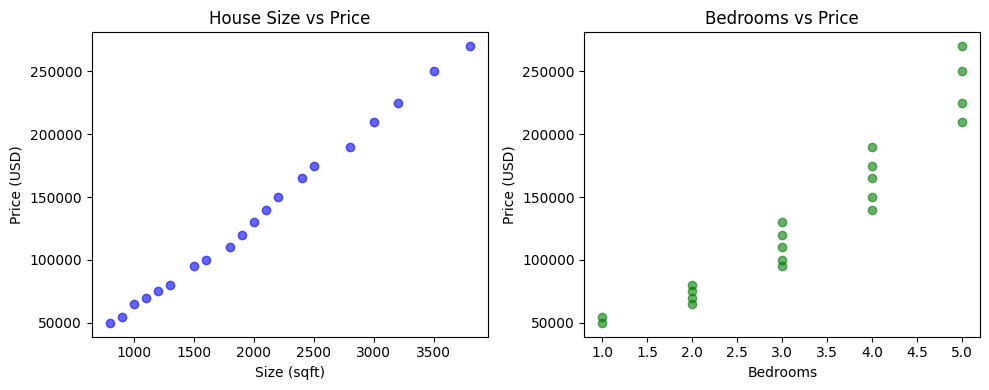

In [4]:
# Plot house size vs price
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(df["size_sqft"], df["price_usd"], color="blue", alpha=0.6)
plt.title("House Size vs Price")
plt.xlabel("Size (sqft)")
plt.ylabel("Price (USD)")

plt.subplot(1, 2, 2)
plt.scatter(df["bedrooms"], df["price_usd"], color="green", alpha=0.6)
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()

In [5]:
# Features and target
X = df[["size_sqft", "bedrooms", "location_score"]]
y = df["price_usd"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel trained successfully!")

Training samples: 16
Testing samples: 4

Model trained successfully!


In [6]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"R2 Score : {r2:.2f}  (1.0 is perfect)")
print(f"MSE      : {mse:.2f}")

# Show actual vs predicted
print("\n=== Actual vs Predicted ===")
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.round(0)
})
print(results)

=== Model Performance ===
R2 Score : 0.99  (1.0 is perfect)
MSE      : 37306313.90

=== Actual vs Predicted ===
   Actual Price  Predicted Price
0         50000          43136.0
1        190000         195761.0
2        140000         141672.0
3         65000          56869.0


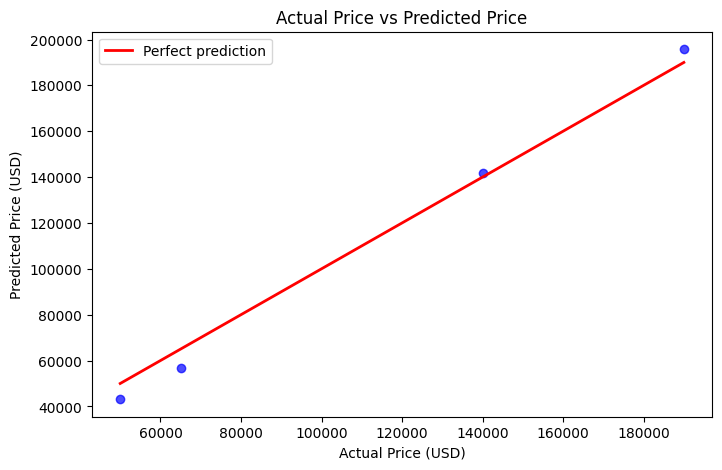

In [7]:
# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color="blue", alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect prediction")
plt.title("Actual Price vs Predicted Price")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.show()

In [8]:
# Predict price for a new house
def predict_price(size, bedrooms, location_score):
    input_data = pd.DataFrame({
        "size_sqft": [size],
        "bedrooms": [bedrooms],
        "location_score": [location_score]
    })
    price = model.predict(input_data)[0]
    return round(price, 2)

# Example prediction
size = 1500
bedrooms = 3
location = 7

predicted = predict_price(size, bedrooms, location)
print("=== House Price Prediction ===")
print(f"Size          : {size} sqft")
print(f"Bedrooms      : {bedrooms}")
print(f"Location Score: {location}/10")
print(f"Predicted Price: ${predicted:,.2f}")

=== House Price Prediction ===
Size          : 1500 sqft
Bedrooms      : 3
Location Score: 7/10
Predicted Price: $94,478.70
